# Nested multi-output GP and March-window sensitivity

This notebook addresses the near-zero length-scale failure found in the first
spatial blocked-validation experiment.

For each of five outer contiguous spatial folds, eight pre-specified pairs of
$H_i/H_s$ length scales are compared using three **inner contiguous folds**.
Only the outer training data select the length scales. The outer held-out block
is used once for evaluation, so there is no test-fold tuning leakage.

The experiment is then repeated on the same fixed row ($y=-487{,}500$ m) for
five March-labelled windows. Despite their folder name, these are 15-day
windows: the preprocessing condition is `midpoint - 7 <= t <= midpoint + 7`.
March 1 and March 29 do not overlap and provide the clearest temporal
replication comparison.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

windows = ['March_1', 'March_8', 'March_15', 'March_22', 'March_29']
data = {
    w: np.genfromtxt(
        f'../results/{w}_nested_gp_predictions.csv', delimiter=',', names=True,
        dtype=None, encoding='utf-8'
    )
    for w in windows
}

print('Rows per fixed-y transect:', {w: len(d) for w, d in data.items()})


Matplotlib is building the font cache; this may take a moment.


Rows per fixed-y transect: {'March_1': 66, 'March_8': 74, 'March_15': 54, 'March_22': 50, 'March_29': 64}


## Held-out freeboard performance


In [2]:
def metrics(actual, predicted):
    error = predicted - actual
    return {
        'RMSE': float(np.sqrt(np.mean(error**2))),
        'MAE': float(np.mean(np.abs(error))),
        'bias': float(np.mean(error)),
    }

results = {}
for w, d in data.items():
    results[w] = {}
    for method, prefix in [('Point + linear', 'point'), ('Nested GP', 'nested_gp')]:
        results[w][method] = {
            'CS2': metrics(d['actual_cs2_m'], d[f'{prefix}_pred_cs2_m']),
            'IS2': metrics(d['actual_is2_m'], d[f'{prefix}_pred_is2_m']),
        }

for w in windows:
    print(w)
    for method in ['Point + linear', 'Nested GP']:
        cs = results[w][method]['CS2']['RMSE']
        laser = results[w][method]['IS2']['RMSE']
        print(f'  {method:14s} CS2={cs:.4f} m  IS2={laser:.4f} m')


March_1
  Point + linear CS2=0.0849 m  IS2=0.1448 m
  Nested GP      CS2=0.1031 m  IS2=0.1352 m
March_8
  Point + linear CS2=0.0628 m  IS2=0.1167 m
  Nested GP      CS2=0.0805 m  IS2=0.1014 m
March_15
  Point + linear CS2=0.0749 m  IS2=0.1351 m
  Nested GP      CS2=0.0834 m  IS2=0.1073 m
March_22
  Point + linear CS2=0.0820 m  IS2=0.1115 m
  Nested GP      CS2=0.1219 m  IS2=0.1772 m
March_29
  Point + linear CS2=0.0527 m  IS2=0.1465 m
  Nested GP      CS2=0.0809 m  IS2=0.1257 m


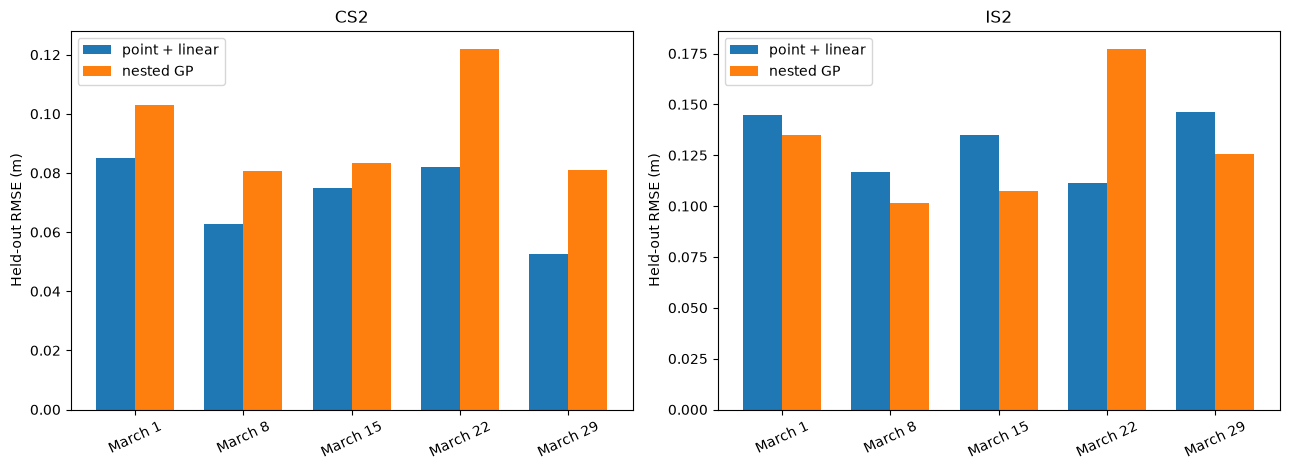

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(windows))
width = 0.36
for j, sensor in enumerate(['CS2', 'IS2']):
    baseline = [results[w]['Point + linear'][sensor]['RMSE'] for w in windows]
    nested = [results[w]['Nested GP'][sensor]['RMSE'] for w in windows]
    axs[j].bar(x-width/2, baseline, width, label='point + linear')
    axs[j].bar(x+width/2, nested, width, label='nested GP')
    axs[j].set_xticks(x, [w.replace('_', ' ') for w in windows], rotation=25)
    axs[j].set_ylabel('Held-out RMSE (m)')
    axs[j].set_title(sensor)
    axs[j].legend()
plt.tight_layout()


## Training-only length-scale selections


March_1 [(300.0, 150.0), (150.0, 75.0), (300.0, 150.0), (400.0, 200.0), (400.0, 200.0)]
March_8 [(200.0, 100.0), (200.0, 100.0), (300.0, 150.0), (200.0, 100.0), (200.0, 100.0)]
March_15 [(150.0, 75.0), (100.0, 50.0), (200.0, 100.0), (150.0, 75.0), (150.0, 75.0)]
March_22 [(400.0, 200.0), (400.0, 200.0), (150.0, 75.0), (150.0, 75.0), (150.0, 75.0)]
March_29 [(200.0, 100.0), (200.0, 100.0), (150.0, 75.0), (400.0, 200.0), (300.0, 150.0)]


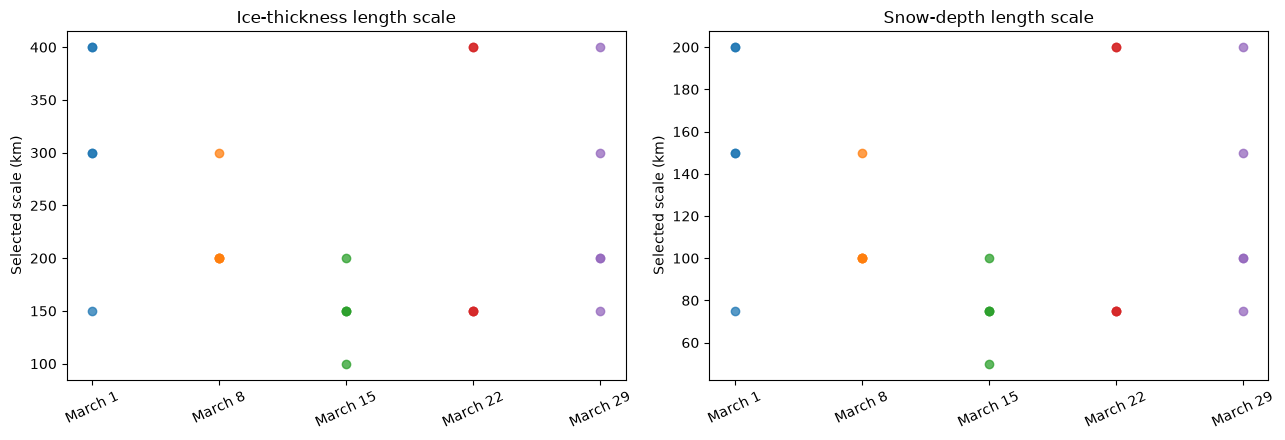

In [4]:
selections = {
    w: json.load(open(f'../results/{w}_nested_gp_selection.json')) for w in windows
}
for w in windows:
    chosen = [(r['selected_Hi_km'], r['selected_Hs_km']) for r in selections[w]]
    print(w, chosen)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for wi, w in enumerate(windows):
    hi = [r['selected_Hi_km'] for r in selections[w]]
    hs = [r['selected_Hs_km'] for r in selections[w]]
    axs[0].scatter(np.full(len(hi), wi), hi, alpha=0.75)
    axs[1].scatter(np.full(len(hs), wi), hs, alpha=0.75)
axs[0].set_title('Ice-thickness length scale')
axs[1].set_title('Snow-depth length scale')
for ax in axs:
    ax.set_xticks(range(len(windows)), [w.replace('_', ' ') for w in windows], rotation=25)
    ax.set_ylabel('Selected scale (km)')
plt.tight_layout()


## Physical diagnostics


In [5]:
for w, d in data.items():
    negative_hi = int((d['nested_gp_Hi_m'] < 0).sum())
    negative_hs = int((d['nested_gp_Hs_m'] < 0).sum())
    print(w, {'negative Hi': negative_hi, 'negative Hs': negative_hs,
              'minimum Hs': float(d['nested_gp_Hs_m'].min())})


March_1 {'negative Hi': 0, 'negative Hs': 0, 'minimum Hs': 7.176220517254861e-05}
March_8 {'negative Hi': 0, 'negative Hs': 0, 'minimum Hs': 0.08713796615213648}
March_15 {'negative Hi': 0, 'negative Hs': 0, 'minimum Hs': 0.02774066090351826}
March_22 {'negative Hi': 0, 'negative Hs': 10, 'minimum Hs': -0.43979157790817536}
March_29 {'negative Hi': 0, 'negative Hs': 0, 'minimum Hs': 0.05003411890288054}


## Evidence-based interpretation

- Nested selection removes the sub-kilometre collapse. Selected ice-thickness
  scales are 100–400 km and snow-depth scales are 50–200 km.
- The nested GP improves held-out IS2 RMSE in four of five windows, including
  both non-overlapping edge windows (March 1 and March 29).
- It does not improve CS2 RMSE in any of the five windows. The gain is therefore
  sensor-specific, not a universal improvement over interpolation.
- March 22 is a clear failure case: GP errors increase for both sensors and ten
  held-out snow estimates become negative. Exact Gaussian latent outputs do not
  enforce the physical constraint $H_s\geq0$.
- The available processed products contain only `x`, `y`, `t`, and freeboard
  `z`. Official quality flags were discarded upstream and cannot be reconstructed
  from these files. A documented quality-filter experiment requires access to
  richer source products or new preprocessing from mission variables.

The next model change should combine nested hyperparameter selection with a
positive latent parameterisation and an explicitly justified CS2/IS2 noise
model. Until then, the simple interpolation model remains the stronger CS2
baseline.
